# Spam SMS / Email Classifier

An end-to-end machine learning project for classifying messages as **HAM** (legitimate) or **SPAM** (unwanted).

### Project Workflow

1. Load and clean the UCI SMS Spam Collection dataset
2. Remove duplicate and invalid records
3. Split the dataset into training and testing sets
4. Convert messages into TF-IDF features
5. Train a Logistic Regression classifier
6. Evaluate the model using accuracy, precision, recall, F1-score, and a confusion matrix
7. Generate predictions with probability/confidence scores

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "SMSSpamCollection"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "spam_classifier.joblib"
)

METRICS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "metrics.csv"
)

EXAMPLES_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "example_predictions.csv"
)

CONFUSION_MATRIX_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "plots"
    / "confusion_matrix.png"
)

METRICS_PLOT_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "plots"
    / "metrics.png"
)

print("Project root:", PROJECT_ROOT)
print("Dataset exists:", DATASET_PATH.exists())
print("Model exists:", MODEL_PATH.exists())

Project root: d:\task2\spam-sms-email-classifier
Dataset exists: True
Model exists: True


In [3]:
import sys

# Add the project folder so Python can import our src modules.
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preprocessing import load_and_clean_dataset

# Load and clean the dataset using our existing project code.
df = load_and_clean_dataset(DATASET_PATH)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", list(df.columns))

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Rows: 5160
Columns: ['label', 'message']

Class distribution:
label
ham     4518
spam     642
Name: count, dtype: int64

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


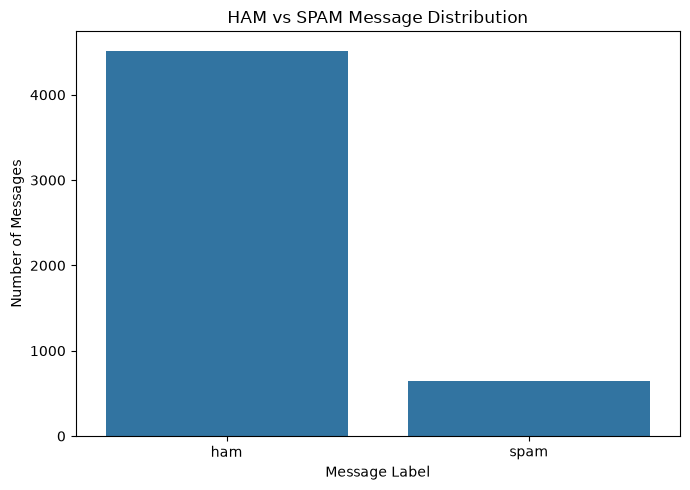

In [4]:
# Count the messages in each class.
class_counts = df["label"].value_counts()

# Create a bar chart.
plt.figure(figsize=(7, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
)

plt.title("HAM vs SPAM Message Distribution")
plt.xlabel("Message Label")
plt.ylabel("Number of Messages")

plt.tight_layout()
plt.show()

In [5]:
# Separate message text (X) from labels (y).
X = df["message"]
y = df["label"]

# Split the data while preserving the HAM/SPAM proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Data split completed!")
print(f"Training messages: {len(X_train)}")
print(f"Testing messages:  {len(X_test)}")

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Data split completed!
Training messages: 4128
Testing messages:  1032

Training class distribution:
label
ham     3614
spam     514
Name: count, dtype: int64

Testing class distribution:
label
ham     904
spam    128
Name: count, dtype: int64


In [6]:
from src.feature_engineering import create_tfidf_vectorizer

# Create the same TF-IDF configuration used by our training script.
tfidf = create_tfidf_vectorizer()

# Learn vocabulary and IDF weights from training messages only.
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test messages using the already-fitted vectorizer.
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF transformation completed!")
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)
print("Number of learned features:", len(tfidf.get_feature_names_out()))

TF-IDF transformation completed!
Training matrix shape: (4128, 10051)
Testing matrix shape: (1032, 10051)
Number of learned features: 10051


In [7]:
# Create Logistic Regression with the project's settings.
classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
)

# Train the classifier using the training features and labels.
classifier.fit(X_train_tfidf, y_train)

print("Model training completed!")
print("Training samples:", len(X_train))
print("Classes learned:", list(classifier.classes_))

Model training completed!
Training samples: 4128
Classes learned: ['ham', 'spam']


In [8]:
# Predict labels for the test messages.
y_pred = classifier.predict(X_test_tfidf)

# Calculate the evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="spam",
    zero_division=0,
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="spam",
    zero_division=0,
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="spam",
    zero_division=0,
)

print("Model Evaluation Results")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Model Evaluation Results
------------------------------
Accuracy : 0.9806
Precision: 0.9030
Recall   : 0.9453
F1-score : 0.9237


In [9]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=["ham", "spam"],
        target_names=["HAM", "SPAM"],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

         HAM       0.99      0.99      0.99       904
        SPAM       0.90      0.95      0.92       128

    accuracy                           0.98      1032
   macro avg       0.95      0.97      0.96      1032
weighted avg       0.98      0.98      0.98      1032



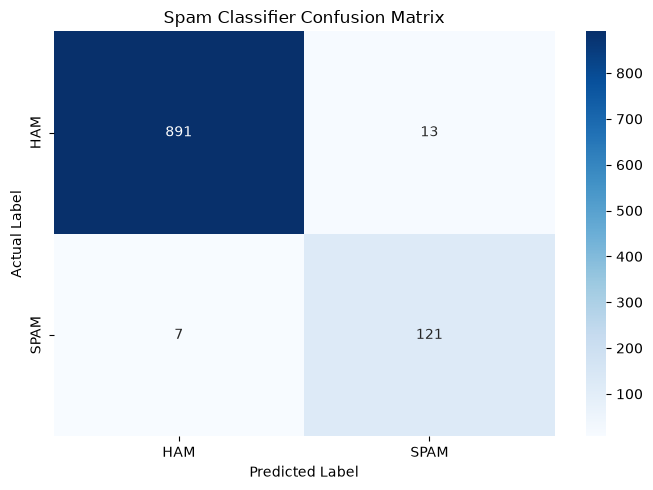

In [10]:
# Compare actual labels with predicted labels.
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["ham", "spam"],
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["HAM", "SPAM"],
    yticklabels=["HAM", "SPAM"],
    cmap="Blues",
)

plt.title("Spam Classifier Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [11]:
# Collect test messages where the predicted label differs from the actual label.
misclassified = pd.DataFrame(
    {
        "message": X_test.to_numpy(),
        "actual_label": y_test.to_numpy(),
        "predicted_label": y_pred,
    }
)

misclassified = misclassified[
    misclassified["actual_label"]
    != misclassified["predicted_label"]
]

print("Number of misclassified messages:", len(misclassified))

display(misclassified.head(20))

Number of misclassified messages: 20


,message,actual_label,predicted_label
86,"Sir, i am waiting for your call, once free ple...",ham,spam
105,I (Career Tel) have added u as a contact on IN...,ham,spam
184,I'm at home. Please call,ham,spam
205,Sorry I missed your call let's talk when you h...,spam,ham
265,I'm at work. Please call,ham,spam
292,Glad to see your reply.,ham,spam
299,LookAtMe!: Thanks for your purchase of a video...,spam,ham
323,Sorry! U can not unsubscribe yet. THE MOB offe...,spam,ham
346,Are you free now?can i call now?,ham,spam
389,Babe: U want me dont u baby! Im nasty and have...,spam,ham


In [12]:
# Get probability estimates for each test message.
test_probabilities = classifier.predict_proba(X_test_tfidf)

# Find which probability column corresponds to each class.
class_names = list(classifier.classes_)
ham_index = class_names.index("ham")
spam_index = class_names.index("spam")

# Create a results table.
test_results = pd.DataFrame(
    {
        "message": X_test.to_numpy(),
        "actual_label": y_test.to_numpy(),
        "predicted_label": y_pred,
        "ham_probability": test_probabilities[:, ham_index],
        "spam_probability": test_probabilities[:, spam_index],
    }
)

test_results["confidence"] = test_probabilities.max(axis=1)

display(test_results.head(10))

,message,actual_label,predicted_label,ham_probability,spam_probability,confidence
0,Can you plz tell me the ans. BSLVYL sent via f...,ham,ham,0.867762,0.132238,0.867762
1,You intrepid duo you! Have a great time and se...,ham,ham,0.853346,0.146654,0.853346
2,R u in this continent?,ham,ham,0.822815,0.177185,0.822815
3,"Cool, want me to go to kappa or should I meet ...",ham,ham,0.817148,0.182852,0.817148
4,I'm meeting Darren...,ham,ham,0.868646,0.131354,0.868646
5,Then u better go sleep.. Dun disturb u liao.. ...,ham,ham,0.941520,0.058480,0.941520
6,"Aight yo, dats straight dogg",ham,ham,0.873828,0.126172,0.873828
7,Hey do you want anything to buy:),ham,ham,0.895311,0.104689,0.895311
8,"No worries, hope photo shoot went well. have a...",ham,ham,0.877694,0.122306,0.877694
9,"sir, you will receive the account no another 1...",ham,ham,0.790661,0.209339,0.790661


In [13]:
# Select predictions where the model's confidence is below 70%.
uncertain_predictions = test_results[
    test_results["confidence"] < 0.70
].sort_values("confidence")

print(
    "Number of predictions below 70% confidence:",
    len(uncertain_predictions),
)

display(uncertain_predictions.head(20))

Number of predictions below 70% confidence: 63


,message,actual_label,predicted_label,ham_probability,spam_probability,confidence
391,(Bank of Granite issues Strong-Buy) EXPLOSIVE ...,spam,spam,0.494830,0.505170,0.505170
523,I liked your new house,ham,spam,0.490502,0.509498,0.509498
556,Yes.. now only saw your message..,ham,spam,0.489362,0.510638,0.510638
948,I got a call from a landline number. . . I am ...,ham,ham,0.515320,0.484680,0.515320
508,Have you laid your airtel line to rest?,ham,spam,0.480458,0.519542,0.519542
883,Plz note: if anyone calling from a mobile Co. ...,ham,ham,0.533650,0.466350,0.533650
317,", ow u dey.i paid 60,400thousad.i told u woul...",ham,ham,0.537543,0.462457,0.537543
846,CLAIRE here am havin borin time & am now alone...,spam,spam,0.460091,0.539909,0.539909
547,Now thats going to ruin your thesis!,ham,ham,0.546466,0.453534,0.546466
621,Dont you have message offer,ham,spam,0.453011,0.546989,0.546989


In [14]:
# Combine TF-IDF and Logistic Regression into one pipeline.
notebook_model = Pipeline(
    steps=[
        ("tfidf", tfidf),
        ("classifier", classifier),
    ]
)

# Save the complete pipeline to the project's outputs folder.
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(notebook_model, MODEL_PATH)

print("Model saved successfully!")
print("Saved location:", MODEL_PATH)
print("File exists:", MODEL_PATH.exists())

Model saved successfully!
Saved location: d:\task2\spam-sms-email-classifier\outputs\spam_classifier.joblib
File exists: True


In [15]:
# Load the pipeline back from disk.
loaded_model = joblib.load(MODEL_PATH)

# Try two sample messages.
sample_messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are we still meeting at 5 today?",
]

sample_predictions = loaded_model.predict(sample_messages)
sample_probabilities = loaded_model.predict_proba(sample_messages)

for message, prediction, probabilities in zip(
    sample_messages,
    sample_predictions,
    sample_probabilities,
):
    confidence = probabilities.max() * 100

    print("Message:", message)
    print("Prediction:", prediction.upper())
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 60)

Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM
Confidence: 97.75%
------------------------------------------------------------
Message: Hey, are we still meeting at 5 today?
Prediction: HAM
Confidence: 93.58%
------------------------------------------------------------


In [16]:
TEST_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "test_predictions.csv"
)

test_results.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False,
)

print("Test predictions saved!")
print("Location:", TEST_PREDICTIONS_PATH)
print("Rows saved:", len(test_results))

Test predictions saved!
Location: d:\task2\spam-sms-email-classifier\outputs\test_predictions.csv
Rows saved: 1032


In [17]:
example_messages = [
    "Congratulations! You have won a free prize. Call now to claim it!",
    "Hey, are we still meeting at 5 today?",
    "URGENT! You have been selected for a cash reward. Reply WIN now!",
    "Can you send me the notes from today's class?",
    "Free entry in a weekly competition to win a brand new mobile phone!",
    "I'll call you when I reach home.",
    "You have won £1000! Text WIN to 87121 to claim your prize.",
    "Don't forget to bring your project tomorrow.",
    "Claim your exclusive free gift now by calling this number.",
    "Are you coming to the library after lunch?",
    "Congratulations! Your mobile number has won a cash prize.",
    "Please let me know when you are free.",
]

example_probabilities = loaded_model.predict_proba(example_messages)
example_labels = loaded_model.predict(example_messages)

class_names = list(loaded_model.classes_)
ham_index = class_names.index("ham")
spam_index = class_names.index("spam")

example_results = pd.DataFrame({
    "message": example_messages,
    "predicted_label": example_labels,
    "ham_probability": example_probabilities[:, ham_index],
    "spam_probability": example_probabilities[:, spam_index],
    "confidence": example_probabilities.max(axis=1),
})

example_results["confidence_percentage"] = (
    example_results["confidence"] * 100
).round(2)

example_results["ham_probability_percentage"] = (
    example_results["ham_probability"] * 100
).round(2)

example_results["spam_probability_percentage"] = (
    example_results["spam_probability"] * 100
).round(2)

example_results.to_csv(EXAMPLES_PATH, index=False)

print("Example predictions saved!")
print("Number of examples:", len(example_results))
display(
    example_results[
        [
            "message",
            "predicted_label",
            "ham_probability_percentage",
            "spam_probability_percentage",
            "confidence_percentage",
        ]
    ]
)

Example predictions saved!
Number of examples: 12


,message,predicted_label,ham_probability_percentage,spam_probability_percentage,confidence_percentage
0,Congratulations! You have won a free prize. Ca...,spam,1.58,98.42,98.42
1,"Hey, are we still meeting at 5 today?",ham,93.58,6.42,93.58
2,URGENT! You have been selected for a cash rewa...,spam,5.23,94.77,94.77
3,Can you send me the notes from today's class?,ham,86.52,13.48,86.52
4,Free entry in a weekly competition to win a br...,spam,14.45,85.55,85.55
5,I'll call you when I reach home.,ham,86.20,13.80,86.20
6,You have won £1000! Text WIN to 87121 to claim...,spam,2.33,97.67,97.67
7,Don't forget to bring your project tomorrow.,ham,74.74,25.26,74.74
8,Claim your exclusive free gift now by calling ...,spam,10.33,89.67,89.67
9,Are you coming to the library after lunch?,ham,89.16,10.84,89.16


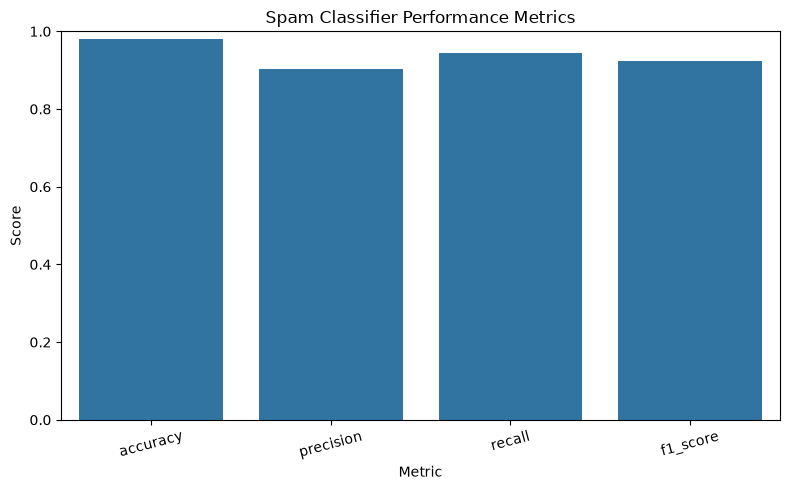

Metrics saved to: d:\task2\spam-sms-email-classifier\outputs\metrics.csv
Metrics chart saved to: d:\task2\spam-sms-email-classifier\outputs\plots\metrics.png


,metric,value
0,accuracy,0.980620
1,precision,0.902985
2,recall,0.945312
3,f1_score,0.923664


In [18]:
# Store the evaluation metrics in a DataFrame.
metrics_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score"],
    "value": [accuracy, precision, recall, f1],
})

# Ensure the output folders exist.
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save the metrics as a CSV file.
metrics_df.to_csv(METRICS_PATH, index=False)

# Create and save the metrics chart.
plt.figure(figsize=(8, 5))

sns.barplot(
    data=metrics_df,
    x="metric",
    y="value",
)

plt.ylim(0, 1)
plt.title("Spam Classifier Performance Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    METRICS_PLOT_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Metrics saved to:", METRICS_PATH)
print("Metrics chart saved to:", METRICS_PLOT_PATH)
display(metrics_df)